# Analisis Performa ConvNeXt-Tiny dalam Pengenalan Ekspresi Wajah pada Dataset FER+

Notebook ini dirapikan mengikuti alur CRISP-DM:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment


## 1. Business Understanding

Tujuan penelitian ini adalah menganalisis performa ConvNeXt-Tiny dalam mengenali ekspresi wajah pada dataset FER+ dan menilai apakah arsitektur tersebut cocok untuk konteks pengenalan ekspresi wajah yang memiliki label anotasi dari beberapa annotator.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%pip install -q timm split-folders

In [ ]:
import os, cv2, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import splitfolders

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler, Dataset
from torchvision import transforms
import timm

from sklearn.metrics import classification_report, confusion_matrix
from torch.optim.lr_scheduler import CosineAnnealingLR

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


## 2. Data Understanding

Pada tahap ini, notebook meninjau masing-masing dataset terlebih dahulu untuk melihat jumlah baris, jumlah kolom, nama kolom, contoh data awal, dan struktur umum sebelum dilakukan pembersihan serta transformasi.

In [ ]:
fer_df     = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Emotion_detection/FER+/icml_face_data.csv')
ferplus_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Emotion_detection/FER+/fer2013new.csv')

fer_df.columns     = fer_df.columns.str.strip()
ferplus_df.columns = ferplus_df.columns.str.strip()

print('=== Data Understanding: FER raw dataset ===')
print(f'Shape         : {fer_df.shape}')
print(f'Jumlah kolom   : {fer_df.shape[1]}')
print(f'Nama kolom     : {list(fer_df.columns)}')
print('\nHead dataset FER:')
display(fer_df.head())
print('\nInfo dataset FER:')
fer_df.info()

print('\n=== Data Understanding: FER+ annotations dataset ===')
print(f'Shape         : {ferplus_df.shape}')
print(f'Jumlah kolom   : {ferplus_df.shape[1]}')
print(f'Nama kolom     : {list(ferplus_df.columns)}')
print('\nHead dataset FER+:')
display(ferplus_df.head())
print('\nInfo dataset FER+:')
ferplus_df.info()

fer_df = fer_df.rename(columns={
    [c for c in fer_df.columns if 'pixel'   in c.lower()][0]: 'pixels',
    [c for c in fer_df.columns if 'usage'   in c.lower()][0]: 'Usage',
    [c for c in fer_df.columns if 'emotion' in c.lower()][0]: 'emotion'
})
ferplus_df = ferplus_df.rename(columns={
    [c for c in ferplus_df.columns if 'usage' in c.lower()][0]: 'Usage'
})

EMOTION_COLS = ['neutral','happiness','surprise','sadness','anger','disgust','fear','contempt']

emotion_votes = ferplus_df[EMOTION_COLS].copy()
nf_votes      = ferplus_df['NF'] if 'NF' in ferplus_df.columns else pd.Series(0, index=ferplus_df.index)
total_votes   = emotion_votes.sum(axis=1)

fer_df['label']       = emotion_votes.idxmax(axis=1)
fer_df['total_votes'] = total_votes
fer_df['nf_votes']    = nf_votes.values

fer_clean = fer_df[
    (fer_df['total_votes'] > 0) &
    (fer_df['label'].isin(EMOTION_COLS)) &
    (fer_df['nf_votes'] < fer_df['total_votes'])  # bukan pure NF
].copy()

soft_label_dict = {}
for orig_idx in fer_clean.index:
    votes = emotion_votes.loc[orig_idx] if orig_idx in emotion_votes.index else None
    if votes is None:
        continue
    total = total_votes.loc[orig_idx]
    soft_label_dict[int(orig_idx)] = (votes / total).values.astype(np.float32)

print(f"Total data valid : {len(fer_clean)}")
print(fer_clean['label'].value_counts())
print(f"Soft label dict  : {len(soft_label_dict)} sampel")

=== Data Understanding: FER raw dataset ===
Shape         : (35887, 3)
Jumlah kolom   : 3
Nama kolom     : ['emotion', 'Usage', 'pixels']

Head dataset FER:


,emotion,Usage,pixels
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,Training,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,Training,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...



Info dataset FER:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   emotion  35887 non-null  int64 
 1   Usage    35887 non-null  object
 2   pixels   35887 non-null  object
dtypes: int64(1), object(2)
memory usage: 841.2+ KB

=== Data Understanding: FER+ annotations dataset ===
Shape         : (35887, 12)
Jumlah kolom   : 12
Nama kolom     : ['Usage', 'Image name', 'neutral', 'happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear', 'contempt', 'unknown', 'NF']

Head dataset FER+:


,Usage,Image name,neutral,happiness,surprise,sadness,anger,disgust,fear,contempt,unknown,NF
0,Training,fer0000000.png,4,0,0,1,3,2,0,0,0,0
1,Training,fer0000001.png,6,0,1,1,0,0,0,0,2,0
2,Training,fer0000002.png,5,0,0,3,1,0,0,0,1,0
3,Training,fer0000003.png,4,0,0,4,1,0,0,0,1,0
4,Training,fer0000004.png,9,0,0,1,0,0,0,0,0,0



Info dataset FER+:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Usage       35887 non-null  object
 1   Image name  35714 non-null  object
 2   neutral     35887 non-null  int64 
 3   happiness   35887 non-null  int64 
 4   surprise    35887 non-null  int64 
 5   sadness     35887 non-null  int64 
 6   anger       35887 non-null  int64 
 7   disgust     35887 non-null  int64 
 8   fear        35887 non-null  int64 
 9   contempt    35887 non-null  int64 
 10  unknown     35887 non-null  int64 
 11  NF          35887 non-null  int64 
dtypes: int64(10), object(2)
memory usage: 3.3+ MB
Total data valid : 35709
label
neutral      13013
happiness     9367
surprise      4493
sadness       4414
anger         3123
fear           825
disgust        253
contempt       221
Name: count, dtype: int64
Soft label dict  : 35709 sampel


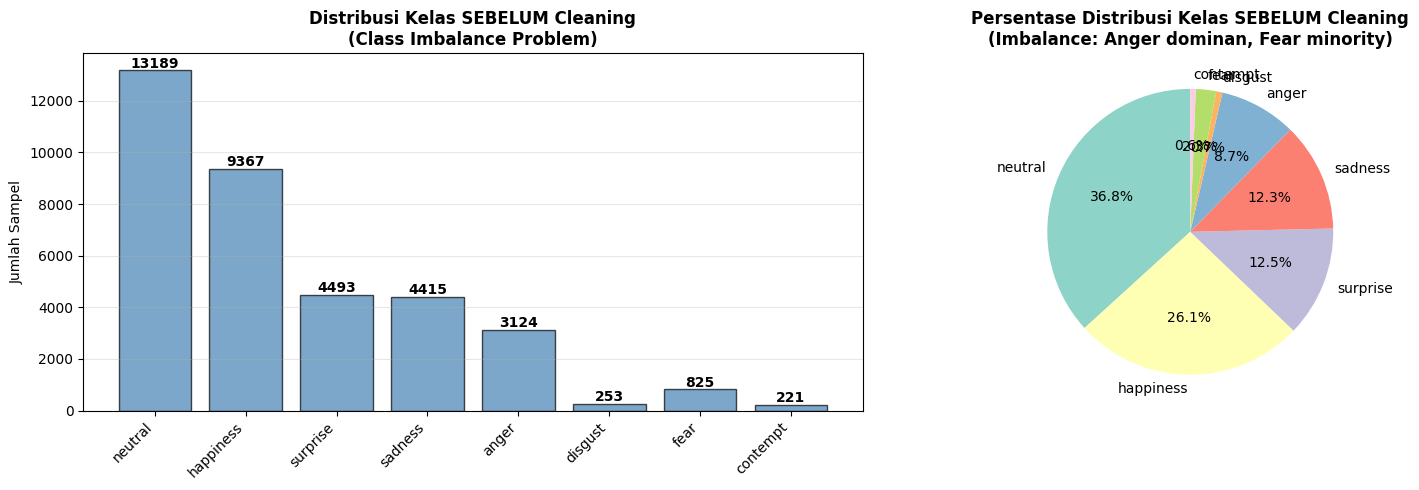

=== CLASS IMBALANCE STATISTICS (SEBELUM CLEANING) ===
Total samples: 35,887
Most frequent: neutral (13,189 samples)
Least frequent: contempt (221 samples)
Imbalance ratio: 59.68x

Distribusi per kelas:
label
neutral      13189
happiness     9367
surprise      4493
sadness       4415
anger         3124
fear           825
disgust        253
contempt       221
Name: count, dtype: int64

⚠️  Kesimpulan: Ada imbalance signifikan → gunakan WeightedRandomSampler di training


In [ ]:
EMOTION_COLS = ['neutral','happiness','surprise','sadness','anger','disgust','fear','contempt']

emotion_votes = ferplus_df[EMOTION_COLS].copy()
total_votes_per_row = emotion_votes.sum(axis=1)

fer_df_temp = fer_df.copy()
fer_df_temp['label'] = emotion_votes.idxmax(axis=1)
fer_df_temp['total_votes'] = total_votes_per_row
fer_df_temp['nf_votes'] = ferplus_df['NF'].values if 'NF' in ferplus_df.columns else 0

label_dist_before = fer_df_temp['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

label_dist_before_sorted = label_dist_before.reindex(EMOTION_COLS, fill_value=0)
axes[0].bar(range(len(label_dist_before_sorted)), label_dist_before_sorted.values, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xticks(range(len(EMOTION_COLS)))
axes[0].set_xticklabels(EMOTION_COLS, rotation=45, ha='right')
axes[0].set_title('Distribusi Kelas SEBELUM Cleaning\n(Class Imbalance Problem)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Jumlah Sampel')
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(label_dist_before_sorted.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

percentages = (label_dist_before_sorted / label_dist_before_sorted.sum() * 100).round(1)
axes[1].pie(label_dist_before_sorted.values, labels=EMOTION_COLS, autopct='%1.1f%%',
            colors=plt.cm.Set3(range(len(EMOTION_COLS))), startangle=90)
axes[1].set_title('Persentase Distribusi Kelas SEBELUM Cleaning\n(Imbalance: Anger dominan, Fear minority)', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('class_distribution_before_cleaning.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== CLASS IMBALANCE STATISTICS (SEBELUM CLEANING) ===")
print(f"Total samples: {label_dist_before.sum():,}")
print(f"Most frequent: {label_dist_before.idxmax()} ({label_dist_before.max():,} samples)")
print(f"Least frequent: {label_dist_before.idxmin()} ({label_dist_before.min():,} samples)")
print(f"Imbalance ratio: {label_dist_before.max() / label_dist_before.min():.2f}x")
print(f"\nDistribusi per kelas:\n{label_dist_before}")
print("\n⚠️  Kesimpulan: Ada imbalance signifikan → gunakan WeightedRandomSampler di training")


## 3. Data Preparation

Setelah struktur data dipahami, data dibersihkan, label diselaraskan, dan citra diekspor ke folder per kelas agar siap dipakai pada proses pelatihan model.

In [ ]:
OUTPUT_BASE = '/content/ferplus_images'

for emotion in EMOTION_COLS:
    os.makedirs(os.path.join(OUTPUT_BASE, emotion), exist_ok=True)

print(f"Mengekspor {len(fer_clean)} gambar...")
for i, (idx, row) in enumerate(fer_clean.iterrows()):
    try:
        pixels   = np.array(row['pixels'].strip().split(), dtype=np.uint8).reshape(48, 48)
        img_rgb  = cv2.cvtColor(pixels, cv2.COLOR_GRAY2RGB)
        cv2.imwrite(os.path.join(OUTPUT_BASE, row['label'], f"img_{idx:07d}.png"), img_rgb)
    except: pass
    if (i+1) % 5000 == 0: print(f"  {i+1}/{len(fer_clean)} done")

print("Ekspor selesai.")

Mengekspor 35709 gambar...
  5000/35709 done
  10000/35709 done
  15000/35709 done
  20000/35709 done
  25000/35709 done
  30000/35709 done
  35000/35709 done
Ekspor selesai.


In [ ]:
SPLIT_OUTPUT = '/content/ferplus_split'
splitfolders.ratio(OUTPUT_BASE, output=SPLIT_OUTPUT, seed=42, ratio=(.8, .1, .1))

for split in ['train','val','test']:
    p = os.path.join(SPLIT_OUTPUT, split)
    total = sum(len(os.listdir(os.path.join(p,e))) for e in os.listdir(p) if os.path.isdir(os.path.join(p,e)))
    print(f"{split}: {total}")

Copying files: 35709 files [00:05, 7114.80 files/s]

train: 28564
val: 3568
test: 3577


In [ ]:
class FERDataset(Dataset):
    def __init__(self, folder, transform=None, class_names=None, soft_label_map=None):
        self.transform = transform
        self.classes = list(class_names) if class_names is not None else sorted(os.listdir(folder))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.soft_label_map = soft_label_map or {}
        self.samples = []
        for cls in self.classes:
            cls_dir = os.path.join(folder, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith('.png'):
                    self.samples.append((os.path.join(cls_dir, fname), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        from PIL import Image
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)

        file_stem = os.path.splitext(os.path.basename(path))[0]
        try:
            orig_idx = int(file_stem.split('_')[-1])
        except ValueError:
            orig_idx = None

        soft_target = self.soft_label_map.get(orig_idx)
        if soft_target is None:
            soft_target = np.zeros(len(self.classes), dtype=np.float32)
            soft_target[label] = 1.0

        soft_target = torch.tensor(soft_target, dtype=torch.float32)
        hard_target = torch.tensor(label, dtype=torch.long)
        return img, soft_target, hard_target

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomAffine(degrees=10),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

train_dataset = FERDataset(os.path.join(SPLIT_OUTPUT, 'train'), train_transform, class_names=EMOTION_COLS, soft_label_map=soft_label_dict)
val_dataset   = FERDataset(os.path.join(SPLIT_OUTPUT, 'val'),   val_transform,   class_names=EMOTION_COLS, soft_label_map=soft_label_dict)
test_dataset  = FERDataset(os.path.join(SPLIT_OUTPUT, 'test'),  val_transform,   class_names=EMOTION_COLS, soft_label_map=soft_label_dict)

NUM_CLASSES = len(train_dataset.classes)
CLASS_NAMES = train_dataset.classes
print(f"Kelas: {CLASS_NAMES}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Kelas: ['neutral', 'happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear', 'contempt']
Train: 28564 | Val: 3568 | Test: 3577


In [ ]:
labels_train = [s[1] for s in train_dataset.samples]
class_counts = np.bincount(labels_train)
class_weights = 1.0 / class_counts                      
sample_weights = [class_weights[l] for l in labels_train]  

sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True
)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=2)

print(f"Train batches: {len(train_loader)}")

Train batches: 893


## 4. Modeling

Tahap ini membangun ConvNeXt-Tiny sebagai model klasifikasi ekspresi wajah dan menyiapkannya untuk proses training.

In [ ]:
model = timm.create_model('convnext_tiny', pretrained=True, num_classes=NUM_CLASSES, drop_rate=0.3, drop_path_rate=0.2)
model = model.to(DEVICE)

USE_GRAPH_MODE = True
if USE_GRAPH_MODE and hasattr(torch, 'compile'):
    try:
        model = torch.compile(model)
        print('Graph mode aktif via torch.compile')
    except Exception as exc:
        print(f'Graph mode tidak aktif, fallback ke eager mode: {exc}')
else:
    print('Graph mode tidak tersedia; tetap memakai eager mode')

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Graph mode aktif via torch.compile
Total params     : 27,826,280
Trainable params : 27,826,280


In [ ]:
criterion = nn.KLDivLoss(reduction='batchmean')

optimizer = optim.Adam(model.parameters(), lr=1e-4)

scheduler = CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)

print('Loss Function: KLDivLoss + soft targets')
print('Soft labels: distribusi vote FER+ per sampel')
print(f"Optimizer: Adam (lr=1e-4)")
print(f"Scheduler: CosineAnnealingLR (T_max=30, eta_min=1e-6)")

Loss Function: KLDivLoss + soft targets
Soft labels: distribusi vote FER+ per sampel
Optimizer: Adam (lr=1e-4)
Scheduler: CosineAnnealingLR (T_max=30, eta_min=1e-6)


In [ ]:
MODEL_MODE = 'graph' if USE_GRAPH_MODE and hasattr(torch, 'compile') else 'eager'
print(f'Training mode: {MODEL_MODE}')

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, soft_targets, labels in loader:
        imgs = imgs.to(DEVICE)
        soft_targets = soft_targets.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        log_probs = F.log_softmax(outputs, dim=1)
        loss = criterion(log_probs, soft_targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, soft_targets, labels in loader:
            imgs = imgs.to(DEVICE)
            soft_targets = soft_targets.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(imgs)
            log_probs = F.log_softmax(outputs, dim=1)
            loss = criterion(log_probs, soft_targets)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(loader), correct / total

EPOCHS = 100
best_val_acc = 0
history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

print(f"Training ConvNeXt-Tiny | {EPOCHS} epochs | device={DEVICE} | mode={MODEL_MODE}")
print("="*60)

patience = 7
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_val_acc = vl_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_convnext_ferplus.pth')
        flag = '← saved'
    else:
        patience_counter += 1
        flag = f'patience {patience_counter}/{patience}'
        if patience_counter >= patience:
            print(f"Early stopping di epoch {epoch}")
            break

    print(f"Ep {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc*100:.2f}% | "
          f"Val Loss: {vl_loss:.4f} Acc: {vl_acc*100:.2f}% {flag}")

print(f"\nBest Val Loss: {best_val_loss:.4f}")
print(f"Best Val Accuracy: {best_val_acc*100:.2f}%")

Training mode: graph
Training ConvNeXt-Tiny | 100 epochs | device=cuda | mode=graph
Ep 01/100 | Train Loss: 0.8435 Acc: 45.45% | Val Loss: 0.4569 Acc: 73.57% ← saved
Ep 02/100 | Train Loss: 0.3579 Acc: 76.48% | Val Loss: 0.3327 Acc: 80.94% ← saved
Ep 03/100 | Train Loss: 0.2761 Acc: 82.10% | Val Loss: 0.3525 Acc: 78.48% patience 1/7
Ep 04/100 | Train Loss: 0.2453 Acc: 83.69% | Val Loss: 0.3081 Acc: 82.40% ← saved
Ep 05/100 | Train Loss: 0.2169 Acc: 85.15% | Val Loss: 0.3078 Acc: 84.33% ← saved
Ep 06/100 | Train Loss: 0.1999 Acc: 86.69% | Val Loss: 0.2948 Acc: 82.23% ← saved
Ep 07/100 | Train Loss: 0.1833 Acc: 87.54% | Val Loss: 0.2793 Acc: 83.13% ← saved
Ep 08/100 | Train Loss: 0.1708 Acc: 87.82% | Val Loss: 0.3058 Acc: 81.08% patience 1/7
Ep 09/100 | Train Loss: 0.1599 Acc: 88.32% | Val Loss: 0.2897 Acc: 83.60% patience 2/7
Ep 10/100 | Train Loss: 0.1466 Acc: 89.13% | Val Loss: 0.2855 Acc: 84.36% patience 3/7
Ep 11/100 | Train Loss: 0.1385 Acc: 89.78% | Val Loss: 0.2883 Acc: 82.93% pa

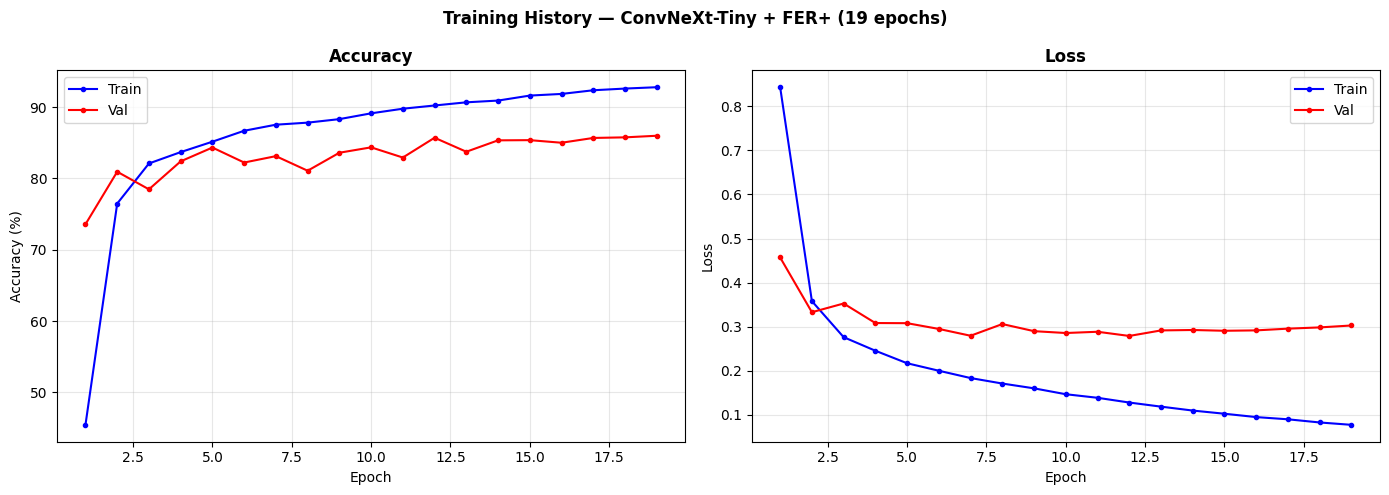

Training berhenti di epoch 19 (early stopping)


In [ ]:
actual_epochs = len(history['train_acc'])  
epochs = range(1, actual_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, [a*100 for a in history['train_acc']], 'b-o', ms=3, label='Train')
axes[0].plot(epochs, [a*100 for a in history['val_acc']],   'r-o', ms=3, label='Val')
axes[0].set_title('Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['train_loss'], 'b-o', ms=3, label='Train')
axes[1].plot(epochs, history['val_loss'],   'r-o', ms=3, label='Val')
axes[1].set_title('Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(f'Training History — ConvNeXt-Tiny + FER+ ({actual_epochs} epochs)', fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Training berhenti di epoch {actual_epochs} (early stopping)")

## 5. Evaluation

Model dievaluasi menggunakan test set untuk melihat akurasi, classification report, dan confusion matrix.

Test Accuracy : 84.74%
Test Loss     : 0.2830

=== Classification Report ===
              precision    recall  f1-score   support

     neutral       0.84      0.88      0.86      1302
   happiness       0.94      0.93      0.93       938
    surprise       0.84      0.89      0.86       450
     sadness       0.78      0.66      0.71       442
       anger       0.79      0.80      0.79       313
     disgust       0.48      0.54      0.51        26
        fear       0.67      0.60      0.63        83
    contempt       0.57      0.52      0.55        23

    accuracy                           0.85      3577
   macro avg       0.74      0.73      0.73      3577
weighted avg       0.85      0.85      0.85      3577



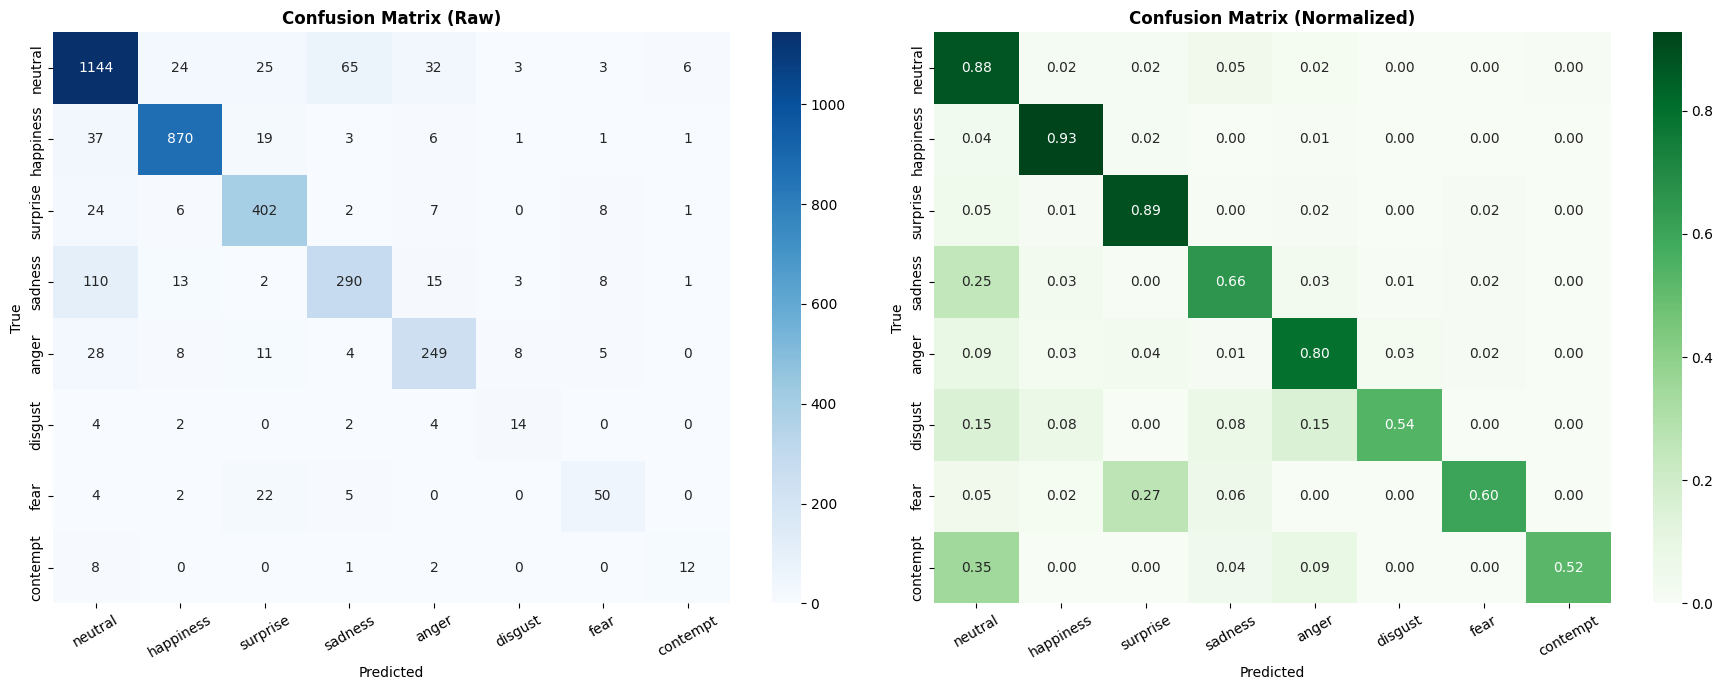

In [ ]:
model.load_state_dict(torch.load('best_convnext_ferplus.pth'))
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for imgs, soft_targets, labels in test_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(labels.numpy())

print("\n=== Classification Report ===")
print(classification_report(all_true, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_true, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, data, fmt, title, cmap in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Confusion Matrix (Raw)', 'Confusion Matrix (Normalized)'],
    ['Blues', 'Greens']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


=== DETAILED PER-CLASS ANALYSIS ===

  Emotion  Precision   Recall  F1-Score  Support
  disgust   0.482759 0.538462  0.509091       26
 contempt   0.571429 0.521739  0.545455       23
     fear   0.666667 0.602410  0.632911       83
  sadness   0.779570 0.656109  0.712531      442
    anger   0.790476 0.795527  0.792994      313
  neutral   0.841795 0.878648  0.859827     1302
 surprise   0.835759 0.893333  0.863588      450
happiness   0.940541 0.927505  0.933977      938

=== KESIMPULAN PER KELAS ===
✅ Kelas Terbaik: happiness (F1=0.934)
❌ Kelas Tersulit: disgust (F1=0.509)
📊 Variasi F1 antar kelas: 0.147 (std dev)

=== TOP MISCLASSIFICATIONS ===
     True Predicted  Count
  sadness   neutral    110
  neutral   sadness     65
happiness   neutral     37
  neutral     anger     32
    anger   neutral     28
  neutral  surprise     25
 surprise   neutral     24
  neutral happiness     24
     fear  surprise     22
happiness  surprise     19


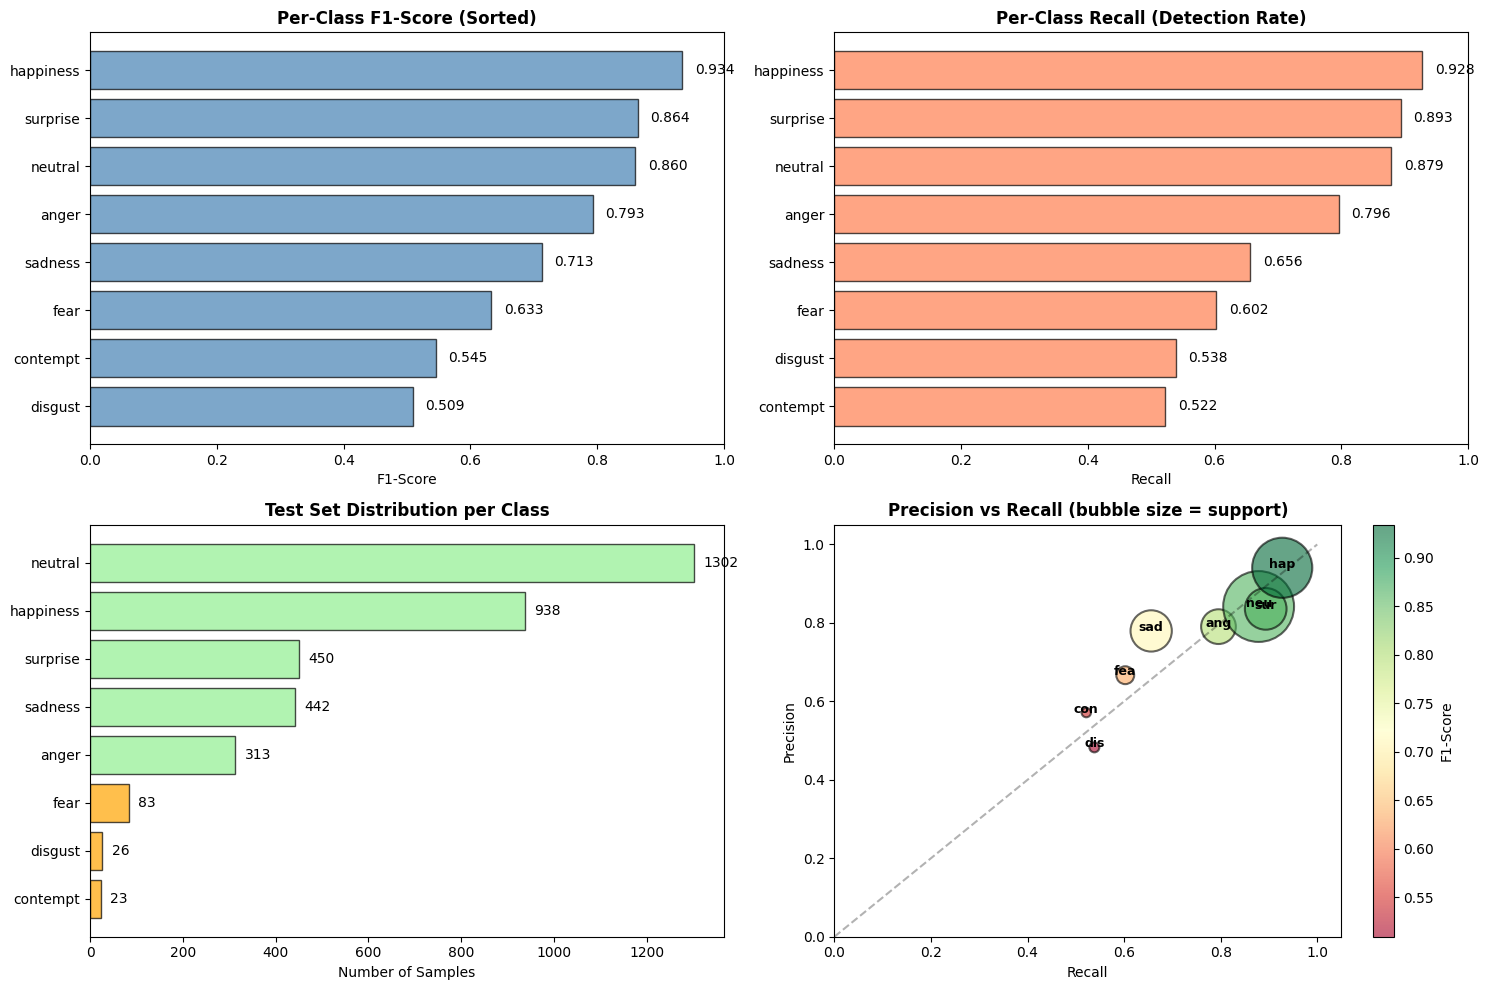


=== INTERPRETASI ===
Model memiliki performa terbaik pada: happiness
Model memiliki performa tersulit pada: disgust

Ratio F1 best/worst: 1.83x


In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    all_true, all_preds, labels=range(NUM_CLASSES)
)

print("\n=== DETAILED PER-CLASS ANALYSIS ===\n")

per_class_df = pd.DataFrame({
    'Emotion': CLASS_NAMES,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
}).sort_values('F1-Score')

print(per_class_df.to_string(index=False))

print("\n=== KESIMPULAN PER KELAS ===")
print(f"✅ Kelas Terbaik: {CLASS_NAMES[f1.argmax()]} (F1={f1.max():.3f})")
print(f"❌ Kelas Tersulit: {CLASS_NAMES[f1.argmin()]} (F1={f1.min():.3f})")
print(f"📊 Variasi F1 antar kelas: {f1.std():.3f} (std dev)")

print("\n=== TOP MISCLASSIFICATIONS ===")
misclassifications = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j:
            misclassifications.append({
                'True': CLASS_NAMES[i],
                'Predicted': CLASS_NAMES[j],
                'Count': cm[i, j]
            })

misclass_df = pd.DataFrame(misclassifications).sort_values('Count', ascending=False).head(10)
print(misclass_df[misclass_df['Count'] > 0].to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

per_class_sorted = per_class_df.sort_values('F1-Score')
axes[0, 0].barh(per_class_sorted['Emotion'], per_class_sorted['F1-Score'],
                 color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('F1-Score')
axes[0, 0].set_title('Per-Class F1-Score (Sorted)', fontweight='bold')
axes[0, 0].set_xlim([0, 1])
for i, v in enumerate(per_class_sorted['F1-Score']):
    axes[0, 0].text(v + 0.02, i, f'{v:.3f}', va='center')


per_class_sorted2 = per_class_df.sort_values('Recall')
axes[0, 1].barh(per_class_sorted2['Emotion'], per_class_sorted2['Recall'],
                 color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_title('Per-Class Recall (Detection Rate)', fontweight='bold')
axes[0, 1].set_xlim([0, 1])
for i, v in enumerate(per_class_sorted2['Recall']):
    axes[0, 1].text(v + 0.02, i, f'{v:.3f}', va='center')


per_class_support = per_class_df.sort_values('Support')
colors_support = ['orange' if s < per_class_df['Support'].quantile(0.33) else 'lightgreen'
                  for s in per_class_support['Support']]
axes[1, 0].barh(per_class_support['Emotion'], per_class_support['Support'],
                 color=colors_support, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Number of Samples')
axes[1, 0].set_title('Test Set Distribution per Class', fontweight='bold')
for i, v in enumerate(per_class_support['Support']):
    axes[1, 0].text(v + 20, i, str(int(v)), va='center')


scatter = axes[1, 1].scatter(per_class_df['Recall'], per_class_df['Precision'],
                             s=per_class_df['Support']*2, alpha=0.6,
                             c=per_class_df['F1-Score'], cmap='RdYlGn',
                             edgecolors='black', linewidth=1.5)
for idx, row in per_class_df.iterrows():
    axes[1, 1].annotate(row['Emotion'][:3],
                       (row['Recall'], row['Precision']),
                       fontsize=9, fontweight='bold', ha='center')
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('Precision vs Recall (bubble size = support)', fontweight='bold')
axes[1, 1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1, 1].set_xlim([0, 1.05])
axes[1, 1].set_ylim([0, 1.05])
cbar = plt.colorbar(scatter, ax=axes[1, 1])
cbar.set_label('F1-Score')

plt.tight_layout()
plt.savefig('per_class_detailed_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== INTERPRETASI ===")
print(f"Model memiliki performa terbaik pada: {per_class_df.iloc[-1]['Emotion']}")
print(f"Model memiliki performa tersulit pada: {per_class_df.iloc[0]['Emotion']}")
print(f"\nRatio F1 best/worst: {per_class_df.iloc[-1]['F1-Score'] / per_class_df.iloc[0]['F1-Score']:.2f}x")


## 6. Deployment

Tahap akhir berisi penyimpanan model ke beberapa format agar hasil penelitian mudah digunakan kembali pada lingkungan lain.

In [ ]:
!pip install -q onnx onnxscript


torch.save(model.state_dict(), 'convnext_ferplus_statedict.pth')
print("Saved: convnext_ferplus_statedict.pth")

torch.save(model, 'convnext_ferplus_fullmodel.pth')
print("Saved: convnext_ferplus_fullmodel.pth")

scripted = torch.jit.script(model.cpu())
scripted.save('convnext_ferplus_scripted.pt')
model = model.to(DEVICE)
print("Saved: convnext_ferplus_scripted.pt")

dummy_input = torch.randn(1, 3, 224, 224).to(DEVICE)
torch.onnx.export(
    model,
    dummy_input,
    'convnext_ferplus.onnx',
    export_params=True,
    opset_version=11,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)
print("Saved: convnext_ferplus.onnx")

torch.save({
    'epoch'               : EPOCHS,
    'model_state_dict'    : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_acc'        : best_val_acc,
    'class_names'         : CLASS_NAMES,
    'history'             : history
}, 'convnext_ferplus_checkpoint.pth')
print("Saved: convnext_ferplus_checkpoint.pth")

print("\nSemua model berhasil disimpan!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 112.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 17.1 MB/s eta 0:00:00
Saved: convnext_ferplus_statedict.pth
Saved: convnext_ferplus_fullmodel.pth


ValueError: Unknown type annotation: 'Callable[..., Any]' at 